In [1]:
!pip install -q -U keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 kB 1.6 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import keras_tuner as kt
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.optimizers import RMSprop
from keras import backend as K
from functools import partial
from pathlib import Path
from tensorflow.keras.datasets import fashion_mnist
from keras.datasets import fashion_mnist
from keras.preprocessing.image import ImageDataGenerator
import os
import keras
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalMaxPooling2D, MaxPooling2D, Activation
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import cifar10
from kerastuner import RandomSearch
from tensorflow.keras.models import Sequential

%matplotlib inline
tf.random.set_seed(42) #reproducible results

<ipython-input-2-11fd6e5cdb7c>:27: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()


(X_train_full1, y_train_full1), (X_test1, y_test1) = fashion_mnist
X_train1, y_train1 = X_train_full1[:-5000], y_train_full1[:-5000]
X_valid1, y_valid1 = X_train_full1[-5000:], y_train_full1[-5000:]
X_train1, X_valid1, X_test1 = X_train1 / 255., X_valid1 / 255., X_test1 / 255. #scale to 0-1


class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


4422102/4422102 [==============================] - 1s 0us/step


MLP Search best hyperparameters

In [ ]:
def build_model(hp):
  n_hidden = hp.Int("n_hidden", min_value=1, max_value=8, default=2)
  n_neurons = hp.Int("n_neurons", min_value=16, max_value=256, step=16)
  learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log", default=1e-3)
  optimizer_choice = hp.Choice("optimizer", values=["sgd", "adam"], default="adam")
  batch_size = hp.Choice("batch_size", values=[16, 32, 64], default=32)
  use_regularization = hp.Boolean("use_regularization", default=False)
  l1_reg = hp.Float("l1_reg", min_value=1e-6, max_value=1e-2, sampling="log", default=1e-6)
  l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log", default=1e-6)
  dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.7, step=0.1, default=0.5)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Flatten())
  for _ in range(n_hidden):
      model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
      if use_regularization:
          model.add(tf.keras.layers.Dropout(rate=dropout_rate))  # Dropout layer for regularization

  model.add(tf.keras.layers.Dense(10, activation="softmax"))

  if use_regularization:
      regularizer = tf.keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
      for layer in model.layers:
          if isinstance(layer, tf.keras.layers.Dense):
              layer.kernel_regularizer = regularizer

  if optimizer_choice == "sgd":
      optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  else:
      optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

  model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
  return model

class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
      return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        batch_size = hp.get("batch_size")
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            X = norm_layer(X)
        return model.fit(X, y, batch_size=batch_size, **kwargs)


In [ ]:
hyperband_tuner = kt.Hyperband(
  MyClassificationHyperModel(), objective="val_accuracy", seed=42,
  max_epochs=10, factor=3, hyperband_iterations=2,
  overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
hyperband_tuner.search(X_train1, y_train1, epochs=10,
                       validation_data=(X_valid1, y_valid1),
                       callbacks=[early_stopping_cb, tensorboard_cb])

top_trials_hyperband = hyperband_tuner.oracle.get_best_trials(num_trials=3)

# Print information about the best 3 models
for idx, trial in enumerate(top_trials_hyperband):
    print(f"Top {idx + 1} Model - Trial ID: {trial.trial_id}")
    print(f"Hyperparameters: {trial.hyperparameters.values}")
    print(f"Final Validation accuracy: {trial.score}")
    print("")


Trial 60 Complete [00h 00m 52s]
val_accuracy: 0.6791999936103821

Best val_accuracy So Far: 0.8899999856948853
Total elapsed time: 00h 46m 39s
Top 1 Model - Trial ID: 0054
Hyperparameters: {'n_hidden': 4, 'n_neurons': 160, 'learning_rate': 0.0005594907608422082, 'optimizer': 'adam', 'batch_size': 32, 'use_regularization': False, 'l1_reg': 3.039546983570397e-06, 'l2_reg': 0.005264322853726466, 'dropout_rate': 0.1, 'normalize': False, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0049'}
Final Validation accuracy: 0.8899999856948853

Top 2 Model - Trial ID: 0055
Hyperparameters: {'n_hidden': 6, 'n_neurons': 112, 'learning_rate': 0.0004426251236616376, 'optimizer': 'adam', 'batch_size': 32, 'use_regularization': False, 'l1_reg': 4.515120371087258e-06, 'l2_reg': 1.0462313885780309e-05, 'dropout_rate': 0.4, 'normalize': False, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0052'}


FIT 3 BEST MLPs

In [ ]:
#1 Fashion MNIST
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_mnist = x_train_mnist.astype('float32') / 255
x_test_mnist = x_test_mnist.astype('float32') / 255

# Convert class labels to one-hot encoded binary class matrices
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# Define hyperparameters
n_hidden_mnist = 4
n_neurons_mnist = 160
learning_rate_mnist = 0.0005594907608422082
batch_size_mnist = 32

# Define input and output shapes
input_shape_mnist = x_train_mnist.shape[1:]
output_shape_mnist = 10

# Build the MLP model
model_mlp1_mnist = Sequential()
model_mlp1_mnist.add(Flatten(input_shape=input_shape_mnist))

# Hidden layers
for _ in range(n_hidden_mnist):
    model_mlp1_mnist.add(Dense(n_neurons_mnist, activation='relu'))
    model_mlp1_mnist.add(Dropout(0.2))

# Output layer
model_mlp1_mnist.add(Dense(output_shape_mnist, activation='softmax'))

# Compile the model
optimizer_mnist = tf.keras.optimizers.Adam(learning_rate=learning_rate_mnist)
model_mlp1_mnist.compile(optimizer=optimizer_mnist, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 100
history_mlp11=model_mlp1_mnist.fit(x_train_mnist, y_train_mnist, batch_size=batch_size_mnist, epochs=epochs, validation_split=0.1)
scores_mlp1_mnist = model_mlp1_mnist.evaluate(x_test_mnist, y_test_mnist, verbose=1)
print('Test loss:', scores_mlp1_mnist[0])
print('Test accuracy:', scores_mlp1_mnist[1])


4422102/4422102 [==============================] - 0s 0us/step
Epoch 1/100
1688/1688 [==============================] - 15s 5ms/step - loss: 0.6363 - accuracy: 0.7709 - val_loss: 0.4306 - val_accuracy: 0.8380
Epoch 2/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4404 - accuracy: 0.8414 - val_loss: 0.3989 - val_accuracy: 0.8532
Epoch 3/100
1688/1688 [==============================] - 7s 4ms/step - loss: 0.3986 - accuracy: 0.8564 - val_loss: 0.3655 - val_accuracy: 0.8630
Epoch 4/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3737 - accuracy: 0.8653 - val_loss: 0.3546 - val_accuracy: 0.8695
Epoch 5/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3574 - accuracy: 0.8696 - val_loss: 0.3441 - val_accuracy: 0.8738
Epoch 6/100
1688/1688 [==============================] - 7s 4ms/step - loss: 0.3429 - accuracy: 0.8769 - val_loss: 0.3330 - val_accuracy: 0.8770
Epoch 7/100
1688/1688 [==============================] - 12s 7ms/s

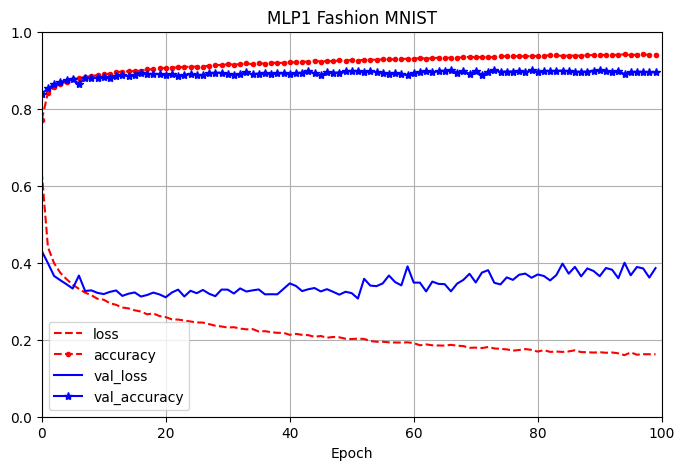

In [ ]:
pd.DataFrame(history_mlp11.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"],title='MLP1 Fashion MNIST')
plt.show()

In [ ]:
# 1 cifar-10
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Convert class vectors to binary class matrices
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define hyperparameters
n_hidden = 4
n_neurons = 160
learning_rate = 0.0005594907608422082
batch_size = 32

# Define input and output shapes
input_shape = x_train.shape[1:]
output_shape = 10

# Build the MLP model
model_mlp1 = Sequential()
model_mlp1.add(tf.keras.layers.Flatten(input_shape=input_shape))

# Hidden layers
for _ in range(n_hidden):
    model_mlp1.add(Dense(n_neurons, activation='relu'))
    model_mlp1.add(Dropout(0.2))
# Output layer
model_mlp1.add(Dense(output_shape, activation='softmax'))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_mlp1.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 100
history_mlp12=model_mlp1.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
scores_mlp1 = model_mlp1.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores_mlp1[0])
print('Test accuracy:', scores_mlp1[1])


170498071/170498071 [==============================] - 4s 0us/step
Epoch 1/100
1407/1407 [==============================] - 9s 5ms/step - loss: 2.0580 - accuracy: 0.2160 - val_loss: 1.9017 - val_accuracy: 0.3024
Epoch 2/100
1407/1407 [==============================] - 6s 5ms/step - loss: 1.9386 - accuracy: 0.2765 - val_loss: 1.8389 - val_accuracy: 0.3266
Epoch 3/100
1407/1407 [==============================] - 7s 5ms/step - loss: 1.9071 - accuracy: 0.2948 - val_loss: 1.8941 - val_accuracy: 0.3048
Epoch 4/100
1407/1407 [==============================] - 7s 5ms/step - loss: 1.8925 - accuracy: 0.3010 - val_loss: 1.8368 - val_accuracy: 0.3410
Epoch 5/100
1407/1407 [==============================] - 7s 5ms/step - loss: 1.8809 - accuracy: 0.3074 - val_loss: 1.7961 - val_accuracy: 0.3448
Epoch 6/100
1407/1407 [==============================] - 6s 5ms/step - loss: 1.8673 - accuracy: 0.3154 - val_loss: 1.8526 - val_accuracy: 0.3350
Epoch 7/100
1407/1407 [==============================] - 7s 5ms

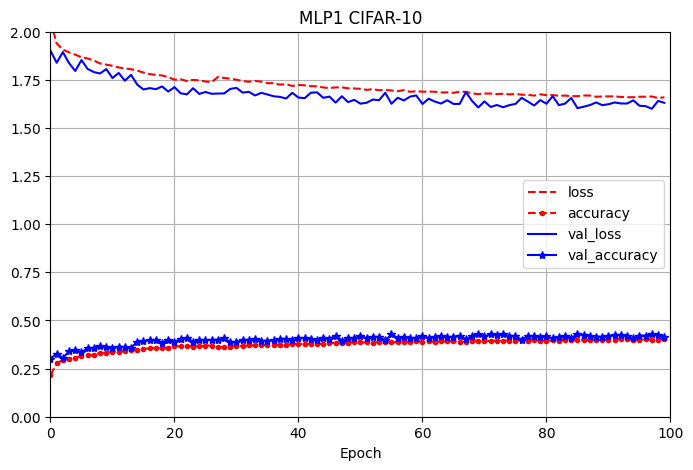

In [ ]:
pd.DataFrame(history_mlp12.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='MLP1 CIFAR-10')
plt.show()

In [ ]:
# 2 fashion mnist

n_hidden = 6
n_neurons = 112
learning_rate = 0.0004426251236616376
batch_size = 32


model_mlp2_mnist = Sequential()
model_mlp2_mnist.add(tf.keras.layers.Flatten(input_shape=input_shape_mnist))


for _ in range(n_hidden):
    model_mlp2_mnist.add(Dense(n_neurons, activation='relu'))
    model_mlp2_mnist.add(Dropout(0.1))

model_mlp2_mnist.add(Dense(output_shape_mnist, activation='softmax'))


optimizer_mnist = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_mlp2_mnist.compile(optimizer=optimizer_mnist, loss='categorical_crossentropy', metrics=['accuracy'])


epochs = 100
history_mlp21=model_mlp2_mnist.fit(x_train_mnist, y_train_mnist, batch_size=batch_size, epochs=epochs, validation_split=0.1)
scores_mlp2_mnist = model_mlp2_mnist.evaluate(x_test_mnist, y_test_mnist, verbose=1)
print('Test loss:', scores_mlp2_mnist[0])
print('Test accuracy:', scores_mlp2_mnist[1])


Epoch 1/100
1688/1688 [==============================] - 12s 6ms/step - loss: 0.6774 - accuracy: 0.7543 - val_loss: 0.4420 - val_accuracy: 0.8398
Epoch 2/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4432 - accuracy: 0.8420 - val_loss: 0.3969 - val_accuracy: 0.8580
Epoch 3/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4003 - accuracy: 0.8568 - val_loss: 0.3734 - val_accuracy: 0.8655
Epoch 4/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3727 - accuracy: 0.8653 - val_loss: 0.3751 - val_accuracy: 0.8660
Epoch 5/100
1688/1688 [==============================] - 9s 6ms/step - loss: 0.3557 - accuracy: 0.8727 - val_loss: 0.3487 - val_accuracy: 0.8733
Epoch 6/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3399 - accuracy: 0.8787 - val_loss: 0.3421 - val_accuracy: 0.8773
Epoch 7/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3291 - accuracy: 0.8807 - val_loss: 0.3409 - val_a

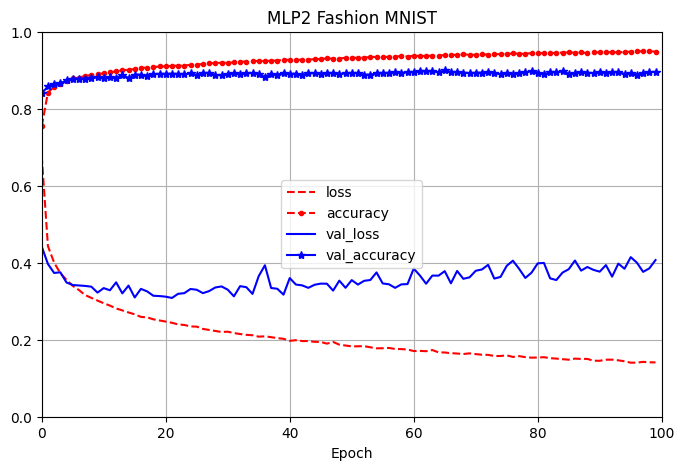

In [ ]:
pd.DataFrame(history_mlp21.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='MLP2 Fashion MNIST')
plt.show()

In [ ]:
# 2 cifar10
# Define hyperparameters
n_hidden = 6
n_neurons = 112
learning_rate = 0.0004426251236616376
batch_size = 32

# Build the MLP model
model_mlp2 = Sequential()
model_mlp2.add(tf.keras.layers.Flatten(input_shape=input_shape))

# Hidden layers
for _ in range(n_hidden):
    model_mlp2.add(Dense(n_neurons, activation='relu'))
    model_mlp2.add(Dropout(0.1))
# Output layer
model_mlp2.add(Dense(output_shape, activation='softmax'))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_mlp2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 100
history_mlp22=model_mlp2.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
scores_mlp2 = model_mlp2.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores_mlp2[0])
print('Test accuracy:', scores_mlp2[1])


Epoch 1/100
1407/1407 [==============================] - 10s 6ms/step - loss: 2.0276 - accuracy: 0.2311 - val_loss: 1.8759 - val_accuracy: 0.3002
Epoch 2/100
1407/1407 [==============================] - 7s 5ms/step - loss: 1.8765 - accuracy: 0.3098 - val_loss: 1.7700 - val_accuracy: 0.3550
Epoch 3/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.8234 - accuracy: 0.3316 - val_loss: 1.7663 - val_accuracy: 0.3654
Epoch 4/100
1407/1407 [==============================] - 8s 5ms/step - loss: 1.7861 - accuracy: 0.3541 - val_loss: 1.7213 - val_accuracy: 0.3822
Epoch 5/100
1407/1407 [==============================] - 8s 5ms/step - loss: 1.7638 - accuracy: 0.3604 - val_loss: 1.7043 - val_accuracy: 0.3930
Epoch 6/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.7434 - accuracy: 0.3647 - val_loss: 1.7146 - val_accuracy: 0.3788
Epoch 7/100
1407/1407 [==============================] - 8s 5ms/step - loss: 1.7320 - accuracy: 0.3710 - val_loss: 1.6791 - val_a

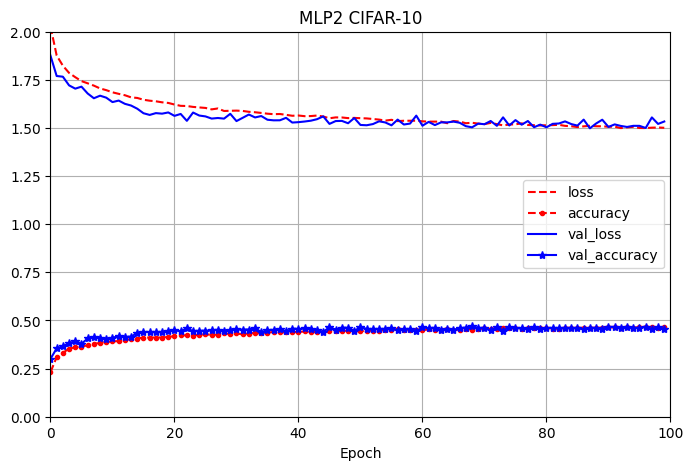

In [ ]:
pd.DataFrame(history_mlp22.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='MLP2 CIFAR-10')
plt.show()

In [ ]:
# 3 fashion mnist

n_hidden = 7
n_neurons = 96
learning_rate = 0.00044489082371598814
batch_size = 32


model_mlp3_mnist = Sequential()
model_mlp3_mnist.add(tf.keras.layers.Flatten(input_shape=input_shape_mnist))


for _ in range(n_hidden):
    model_mlp3_mnist.add(Dense(n_neurons, activation='relu'))
    model_mlp3_mnist.add(Dropout(0.1))

model_mlp3_mnist.add(Dense(output_shape_mnist, activation='softmax'))


optimizer_mnist = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_mlp3_mnist.compile(optimizer=optimizer_mnist, loss='categorical_crossentropy', metrics=['accuracy'])


epochs = 100
history_mlp31=model_mlp3_mnist.fit(x_train_mnist, y_train_mnist, batch_size=batch_size, epochs=epochs, validation_split=0.1)
scores_mlp3_mnist = model_mlp3_mnist.evaluate(x_test_mnist, y_test_mnist, verbose=1)
print('Test loss:', scores_mlp3_mnist[0])
print('Test accuracy:', scores_mlp3_mnist[1])



Epoch 1/100
1688/1688 [==============================] - 13s 6ms/step - loss: 0.7298 - accuracy: 0.7281 - val_loss: 0.4506 - val_accuracy: 0.8362
Epoch 2/100
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4687 - accuracy: 0.8338 - val_loss: 0.3964 - val_accuracy: 0.8583
Epoch 3/100
1688/1688 [==============================] - 10s 6ms/step - loss: 0.4191 - accuracy: 0.8502 - val_loss: 0.3971 - val_accuracy: 0.8577
Epoch 4/100
1688/1688 [==============================] - 10s 6ms/step - loss: 0.3874 - accuracy: 0.8614 - val_loss: 0.3687 - val_accuracy: 0.8657
Epoch 5/100
1688/1688 [==============================] - 10s 6ms/step - loss: 0.3731 - accuracy: 0.8670 - val_loss: 0.3501 - val_accuracy: 0.8707
Epoch 6/100
1688/1688 [==============================] - 9s 6ms/step - loss: 0.3555 - accuracy: 0.8749 - val_loss: 0.3527 - val_accuracy: 0.8742
Epoch 7/100
1688/1688 [==============================] - 10s 6ms/step - loss: 0.3432 - accuracy: 0.8793 - val_loss: 0.3478 - v

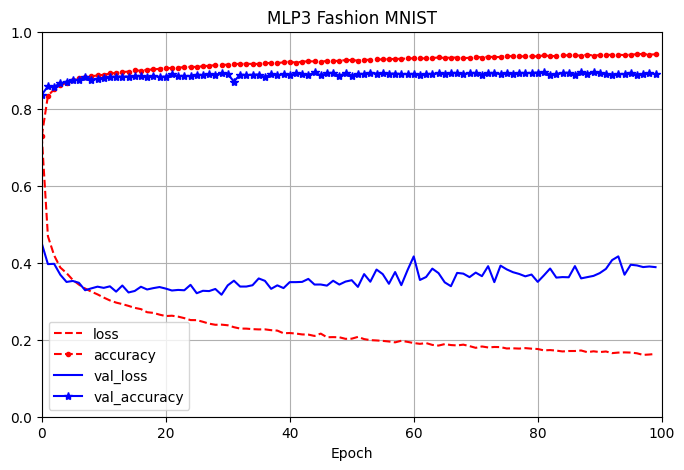

In [ ]:
pd.DataFrame(history_mlp31.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 1 ], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='MLP3 Fashion MNIST')
plt.show()

In [ ]:
# 3 cifar 10
# Define hyperparameters
n_hidden = 7
n_neurons = 96
learning_rate = 0.00044489082371598814
batch_size = 32

# Build the MLP model
model_mlp3 = Sequential()
model_mlp3.add(tf.keras.layers.Flatten(input_shape=input_shape))

# Hidden layers
for _ in range(n_hidden):
    model_mlp3.add(Dense(n_neurons, activation='relu'))
    model_mlp3.add(Dropout(0.1))
# Output layer
model_mlp3.add(Dense(output_shape, activation='softmax'))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_mlp3.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 100
history_mlp32=model_mlp3.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
scores_mlp3 = model_mlp3.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores_mlp3[0])
print('Test accuracy:', scores_mlp3[1])


Epoch 1/100
1407/1407 [==============================] - 11s 6ms/step - loss: 2.0572 - accuracy: 0.2159 - val_loss: 1.9178 - val_accuracy: 0.2872
Epoch 2/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.9162 - accuracy: 0.2916 - val_loss: 1.8213 - val_accuracy: 0.3352
Epoch 3/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.8649 - accuracy: 0.3143 - val_loss: 1.8251 - val_accuracy: 0.3462
Epoch 4/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.8400 - accuracy: 0.3316 - val_loss: 1.7860 - val_accuracy: 0.3618
Epoch 5/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.8202 - accuracy: 0.3393 - val_loss: 1.7739 - val_accuracy: 0.3680
Epoch 6/100
1407/1407 [==============================] - 8s 6ms/step - loss: 1.8000 - accuracy: 0.3487 - val_loss: 1.7335 - val_accuracy: 0.3812
Epoch 7/100
1407/1407 [==============================] - 9s 6ms/step - loss: 1.7886 - accuracy: 0.3516 - val_loss: 1.7547 - val_a

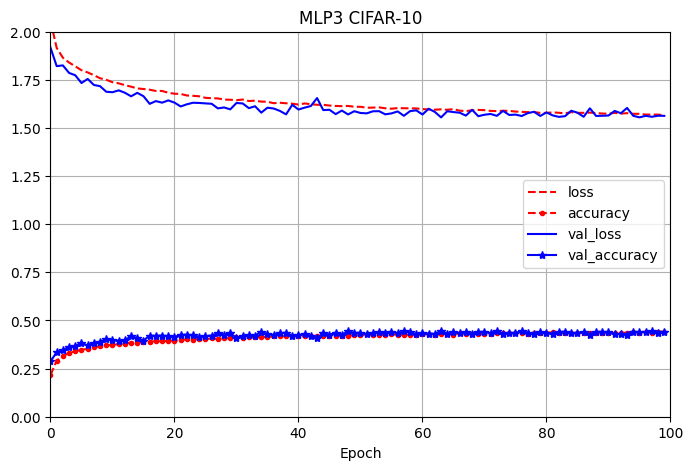

In [ ]:
pd.DataFrame(history_mlp32.history).plot(
figsize=(8, 5), xlim=[0, 100], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='MLP3 CIFAR-10')
plt.show()

CNN Search best hyperparameters

In [ ]:
df = tf.keras.datasets.fashion_mnist

(train_df,train_labl),(test_df,test_labl) = df.load_data()


train_df=train_df/255.0

test_df = test_df/255.0


train_df = train_df.reshape(len(train_df),28,28,1)
test_df = test_df.reshape(len(test_df),28,28,1)

def build_model(hp):
    
    model = keras.Sequential([
    
    keras.layers.Conv2D(
        
        filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
        
        kernel_size=hp.Choice('conv_1_kernel', values = [3,5]),
        #activation function
        activation='relu',
        input_shape=(28,28,1)),
   
    keras.layers.Conv2D(
        
        filters=hp.Int('conv_2_filter', min_value=32, max_value=64, step=16),
        
        kernel_size=hp.Choice('conv_2_kernel', values = [3,5]),
        
        activation='relu'
    ),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(
        units=hp.Int('dense_1_units', min_value=32, max_value=128, step=16),
        activation='relu'
    ),
    
    keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3])),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return model




In [ ]:
hyperband_tuner = kt.Hyperband(build_model, objective="val_accuracy", seed=42,
  max_epochs=10, factor=3, hyperband_iterations=2,
  overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
hyperband_tuner.search(train_df,train_labl, epochs=10,
                       validation_split=0.1,
                       callbacks=[early_stopping_cb, tensorboard_cb])

top_trials_hyperband = hyperband_tuner.oracle.get_best_trials(num_trials=3)

# Print information about the best 3 models
for idx, trial in enumerate(top_trials_hyperband):
    print(f"Top {idx + 1} Model - Trial ID: {trial.trial_id}")
    print(f"Hyperparameters: {trial.hyperparameters.values}")
    print(f"Final Validation accuracy: {trial.score}")
    print("")

Trial 60 Complete [00h 00m 54s]
val_accuracy: 0.9100000262260437

Best val_accuracy So Far: 0.9175000190734863
Total elapsed time: 00h 43m 49s
Top 1 Model - Trial ID: 0055
Hyperparameters: {'conv_1_filter': 112, 'conv_1_kernel': 3, 'conv_2_filter': 64, 'conv_2_kernel': 3, 'dense_1_units': 48, 'learning_rate': 0.001, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0051'}
Final Validation accuracy: 0.9175000190734863

Top 2 Model - Trial ID: 0024
Hyperparameters: {'conv_1_filter': 48, 'conv_1_kernel': 3, 'conv_2_filter': 64, 'conv_2_kernel': 5, 'dense_1_units': 96, 'learning_rate': 0.001, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0021'}
Final Validation accuracy: 0.9171666502952576

Top 3 Model - Trial ID: 0029
Hyperparameters: {'conv_1_filter': 112, 'conv_1_kernel': 3, 'conv_2_filter': 32, 'conv_2_kernel': 5, 'dense_1_units': 128, 'learning_rate': 0.001, 'tuner/epochs': 10

FIT 3 BEST CNN

In [5]:
## 1 mnist

(train_df, train_labl), (test_df, test_labl) = fashion_mnist.load_data()


train_df = train_df.reshape(train_df.shape[0], 28, 28, 1).astype('float32') / 255.0
test_df = test_df.reshape(test_df.shape[0], 28, 28, 1).astype('float32') / 255.0


train_labl = tf.keras.utils.to_categorical(train_labl, 10)
test_labl = tf.keras.utils.to_categorical(test_labl, 10)


best_hyperparameters = {'conv_1_filter': 112,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 64,
                        'conv_2_kernel': (3, 3),
                        'dense_1_units': 48,
                        'learning_rate': 0.001}


model21 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model21.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_cnn21=model21.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores21 = model21.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores21[0])
print('Test accuracy:', scores21[1])


4422102/4422102 [==============================] - 1s 0us/step
Epoch 1/25
844/844 [==============================] - 15s 13ms/step - loss: 0.5987 - accuracy: 0.7987 - val_loss: 0.3334 - val_accuracy: 0.8747
Epoch 2/25
844/844 [==============================] - 11s 13ms/step - loss: 0.3980 - accuracy: 0.8653 - val_loss: 0.2831 - val_accuracy: 0.8983
Epoch 3/25
844/844 [==============================] - 11s 13ms/step - loss: 0.3386 - accuracy: 0.8860 - val_loss: 0.2884 - val_accuracy: 0.8992
Epoch 4/25
844/844 [==============================] - 11s 13ms/step - loss: 0.3007 - accuracy: 0.8966 - val_loss: 0.2492 - val_accuracy: 0.9077
Epoch 5/25
844/844 [==============================] - 11s 13ms/step - loss: 0.2811 - accuracy: 0.9031 - val_loss: 0.2554 - val_accuracy: 0.9063
Epoch 6/25
844/844 [==============================] - 11s 13ms/step - loss: 0.2584 - accuracy: 0.9118 - val_loss: 0.2507 - val_accuracy: 0.9078
Epoch 7/25
844/844 [==============================] - 11s 13ms/step - los

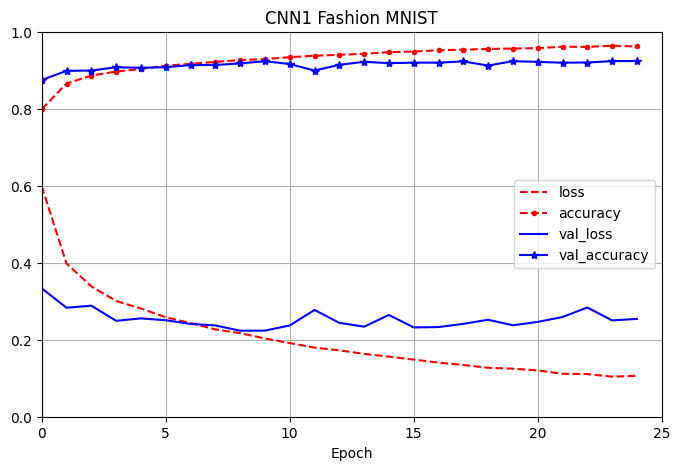

In [21]:
pd.DataFrame(history_cnn21.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN1 Fashion MNIST')
plt.show()

In [7]:
## 1 cifar

(train_df, train_labl), (test_df, test_labl) = cifar10.load_data()


train_df = train_df / 255.0
test_df = test_df / 255.0

best_hyperparameters = {'conv_1_filter': 112,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 64,
                        'conv_2_kernel': (3, 3),
                        'dense_1_units': 48,
                        'learning_rate': 0.001}


model22 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model22.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_cnn22=model22.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores22 = model22.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores22[0])
print('Test accuracy:', scores22[1])


Epoch 1/25
704/704 [==============================] - 14s 16ms/step - loss: 1.8250 - accuracy: 0.3816 - val_loss: 1.5708 - val_accuracy: 0.4462
Epoch 2/25
704/704 [==============================] - 11s 16ms/step - loss: 1.4075 - accuracy: 0.4998 - val_loss: 1.2589 - val_accuracy: 0.5548
Epoch 3/25
704/704 [==============================] - 11s 16ms/step - loss: 1.2724 - accuracy: 0.5519 - val_loss: 1.3065 - val_accuracy: 0.5516
Epoch 4/25
704/704 [==============================] - 11s 16ms/step - loss: 1.1733 - accuracy: 0.5836 - val_loss: 1.0725 - val_accuracy: 0.6224
Epoch 5/25
704/704 [==============================] - 11s 16ms/step - loss: 1.0881 - accuracy: 0.6171 - val_loss: 1.0616 - val_accuracy: 0.6242
Epoch 6/25
704/704 [==============================] - 11s 16ms/step - loss: 1.0270 - accuracy: 0.6417 - val_loss: 1.0499 - val_accuracy: 0.6336
Epoch 7/25
704/704 [==============================] - 11s 16ms/step - loss: 0.9652 - accuracy: 0.6670 - val_loss: 1.0123 - val_accuracy:

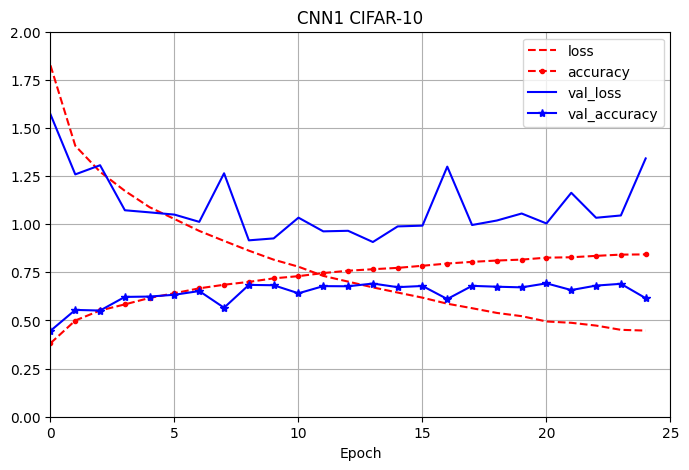

In [22]:
pd.DataFrame(history_cnn22.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN1 CIFAR-10')
plt.show()

In [13]:
## 2 mnist

(train_df, train_labl), (test_df, test_labl) = fashion_mnist.load_data()


train_df = train_df.reshape(train_df.shape[0], 28, 28, 1).astype('float32') / 255.0
test_df = test_df.reshape(test_df.shape[0], 28, 28, 1).astype('float32') / 255.0


train_labl = tf.keras.utils.to_categorical(train_labl, 10)
test_labl = tf.keras.utils.to_categorical(test_labl, 10)


best_hyperparameters = {'conv_1_filter': 48,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 64,
                        'conv_2_kernel': (5, 5),
                        'dense_1_units': 96,
                        'learning_rate': 0.001}


model41 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model41.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn41=model41.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores41 = model41.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores41[0])
print('Test accuracy:', scores41[1])


Epoch 1/25
844/844 [==============================] - 11s 10ms/step - loss: 0.5630 - accuracy: 0.8067 - val_loss: 0.3490 - val_accuracy: 0.8715
Epoch 2/25
844/844 [==============================] - 8s 10ms/step - loss: 0.3658 - accuracy: 0.8698 - val_loss: 0.2842 - val_accuracy: 0.8992
Epoch 3/25
844/844 [==============================] - 8s 10ms/step - loss: 0.3175 - accuracy: 0.8877 - val_loss: 0.2645 - val_accuracy: 0.9025
Epoch 4/25
844/844 [==============================] - 8s 10ms/step - loss: 0.2845 - accuracy: 0.8993 - val_loss: 0.3015 - val_accuracy: 0.8812
Epoch 5/25
844/844 [==============================] - 11s 13ms/step - loss: 0.2639 - accuracy: 0.9058 - val_loss: 0.2439 - val_accuracy: 0.9122
Epoch 6/25
844/844 [==============================] - 9s 11ms/step - loss: 0.2433 - accuracy: 0.9136 - val_loss: 0.2478 - val_accuracy: 0.9113
Epoch 7/25
844/844 [==============================] - 8s 9ms/step - loss: 0.2262 - accuracy: 0.9199 - val_loss: 0.2316 - val_accuracy: 0.915

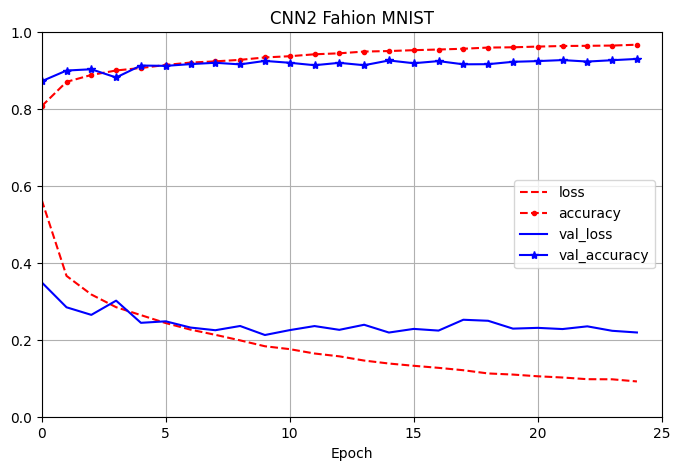

In [14]:
pd.DataFrame(history_cnn41.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN2 Fahion MNIST')
plt.show()

In [15]:
## 2 cifar
# Load CIFAR-10 dataset
(train_df, train_labl), (test_df, test_labl) = cifar10.load_data()


train_df = train_df / 255.0
test_df = test_df / 255.0

best_hyperparameters = {'conv_1_filter': 48,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 64,
                        'conv_2_kernel': (5, 5),
                        'dense_1_units': 96,
                        'learning_rate': 0.001}


model42 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model42.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_cnn42=model42.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores42 = model42.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores42[0])
print('Test accuracy:', scores42[1])


Epoch 1/25
704/704 [==============================] - 11s 13ms/step - loss: 1.7568 - accuracy: 0.4130 - val_loss: 1.5571 - val_accuracy: 0.4378
Epoch 2/25
704/704 [==============================] - 8s 12ms/step - loss: 1.2853 - accuracy: 0.5431 - val_loss: 1.3506 - val_accuracy: 0.5034
Epoch 3/25
704/704 [==============================] - 9s 12ms/step - loss: 1.1166 - accuracy: 0.6067 - val_loss: 1.0821 - val_accuracy: 0.6300
Epoch 4/25
704/704 [==============================] - 9s 12ms/step - loss: 1.0182 - accuracy: 0.6438 - val_loss: 0.9543 - val_accuracy: 0.6564
Epoch 5/25
704/704 [==============================] - 8s 12ms/step - loss: 0.9384 - accuracy: 0.6720 - val_loss: 0.9707 - val_accuracy: 0.6562
Epoch 6/25
704/704 [==============================] - 9s 12ms/step - loss: 0.8637 - accuracy: 0.6981 - val_loss: 0.9464 - val_accuracy: 0.6664
Epoch 7/25
704/704 [==============================] - 9s 12ms/step - loss: 0.8061 - accuracy: 0.7180 - val_loss: 1.1053 - val_accuracy: 0.636

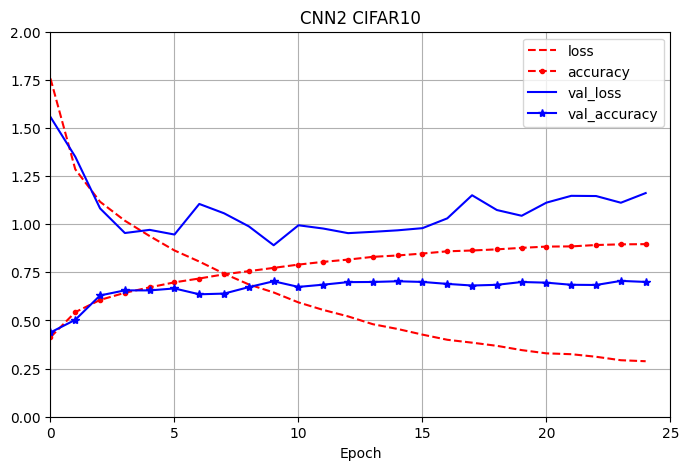

In [16]:
pd.DataFrame(history_cnn42.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN2 CIFAR10')
plt.show()

In [17]:
## 3 mnist

(train_df, train_labl), (test_df, test_labl) = fashion_mnist.load_data()


train_df = train_df.reshape(train_df.shape[0], 28, 28, 1).astype('float32') / 255.0
test_df = test_df.reshape(test_df.shape[0], 28, 28, 1).astype('float32') / 255.0


train_labl = tf.keras.utils.to_categorical(train_labl, 10)
test_labl = tf.keras.utils.to_categorical(test_labl, 10)


best_hyperparameters = {'conv_1_filter': 112,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 32,
                        'conv_2_kernel': (5, 5),
                        'dense_1_units': 128,
                        'learning_rate': 0.001}


model51 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model51.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_cnn51=model51.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores51 = model51.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores51[0])
print('Test accuracy:', scores51[1])


Epoch 1/25
844/844 [==============================] - 13s 13ms/step - loss: 0.5395 - accuracy: 0.8150 - val_loss: 0.3315 - val_accuracy: 0.8747
Epoch 2/25
844/844 [==============================] - 10s 12ms/step - loss: 0.3552 - accuracy: 0.8735 - val_loss: 0.2983 - val_accuracy: 0.8927
Epoch 3/25
844/844 [==============================] - 10s 12ms/step - loss: 0.3037 - accuracy: 0.8911 - val_loss: 0.2936 - val_accuracy: 0.8913
Epoch 4/25
844/844 [==============================] - 10s 12ms/step - loss: 0.2711 - accuracy: 0.9014 - val_loss: 0.2584 - val_accuracy: 0.9063
Epoch 5/25
844/844 [==============================] - 11s 13ms/step - loss: 0.2491 - accuracy: 0.9089 - val_loss: 0.2391 - val_accuracy: 0.9100
Epoch 6/25
844/844 [==============================] - 10s 12ms/step - loss: 0.2325 - accuracy: 0.9155 - val_loss: 0.2915 - val_accuracy: 0.8910
Epoch 7/25
844/844 [==============================] - 11s 12ms/step - loss: 0.2136 - accuracy: 0.9227 - val_loss: 0.2335 - val_accuracy:

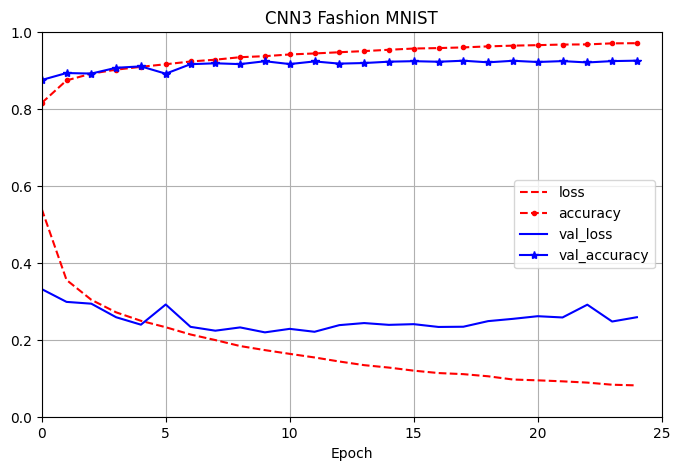

In [18]:
pd.DataFrame(history_cnn51.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN3 Fashion MNIST')
plt.show()

In [19]:
## 3 cifar

(train_df, train_labl), (test_df, test_labl) = cifar10.load_data()


train_df = train_df / 255.0
test_df = test_df / 255.0

best_hyperparameters = {'conv_1_filter': 112,
                        'conv_1_kernel': (3, 3),
                        'conv_2_filter': 32,
                        'conv_2_kernel': (5, 5),
                        'dense_1_units': 128,
                        'learning_rate': 0.001}


model52 = Sequential([
    Conv2D(
        filters=best_hyperparameters['conv_1_filter'],
        kernel_size=best_hyperparameters['conv_1_kernel'],
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    Dropout(0.6),
    BatchNormalization(),
    Conv2D(
        filters=best_hyperparameters['conv_2_filter'],
        kernel_size=best_hyperparameters['conv_2_kernel'],
        activation='relu'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(
        units=best_hyperparameters['dense_1_units'],
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.6),
    Dense(10, activation='softmax')
])


model52.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparameters['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_cnn52=model52.fit(train_df, train_labl, epochs=25, batch_size=64, validation_split=0.1)
scores52 = model52.evaluate(test_df, test_labl, verbose=1)
print('Test loss:', scores52[0])
print('Test accuracy:', scores52[1])


Epoch 1/25
704/704 [==============================] - 13s 15ms/step - loss: 1.7556 - accuracy: 0.4182 - val_loss: 2.2242 - val_accuracy: 0.3332
Epoch 2/25
704/704 [==============================] - 11s 15ms/step - loss: 1.2800 - accuracy: 0.5467 - val_loss: 1.1397 - val_accuracy: 0.5876
Epoch 3/25
704/704 [==============================] - 10s 15ms/step - loss: 1.1276 - accuracy: 0.6016 - val_loss: 1.2325 - val_accuracy: 0.5760
Epoch 4/25
704/704 [==============================] - 10s 15ms/step - loss: 1.0320 - accuracy: 0.6394 - val_loss: 1.1406 - val_accuracy: 0.6002
Epoch 5/25
704/704 [==============================] - 11s 15ms/step - loss: 0.9645 - accuracy: 0.6616 - val_loss: 1.4672 - val_accuracy: 0.5506
Epoch 6/25
704/704 [==============================] - 10s 15ms/step - loss: 0.9032 - accuracy: 0.6810 - val_loss: 1.0015 - val_accuracy: 0.6494
Epoch 7/25
704/704 [==============================] - 10s 15ms/step - loss: 0.8520 - accuracy: 0.7009 - val_loss: 1.0944 - val_accuracy:

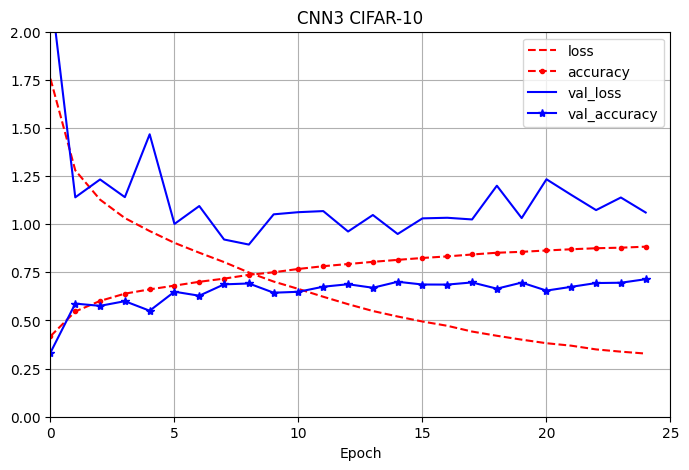

In [20]:
pd.DataFrame(history_cnn52.history).plot(
figsize=(8, 5), xlim=[0, 25], ylim=[0, 2], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"], title='CNN3 CIFAR-10')
plt.show()